In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image

In [90]:
class TresureHunt:
    def __init__(self,filename):
        self.im = cv2.imread(filename) # Reading image
        self.bin_im = None
        self.stats = None
        self.centroids = None
        self.arrow_ind = None
        self.overall_path = None
        
    def binarisation(self):
        # Binarisation
        bin_threshold = 60; # parameter to vary
        gray = cv2.cvtColor(self.im, cv2.COLOR_BGR2GRAY)
        ret,bin_im = cv2.threshold(gray, bin_threshold, 255, cv2.THRESH_BINARY)

        ##Image Hole hole
        img = bin_im.copy()  # binary image (0 background, 255 foreground)
        h, w = img.shape
        mask = np.zeros((h+2, w+2), np.uint8)
    
        # Step 1: flood fill the background
        floodfilled = img.copy()
        cv2.floodFill(floodfilled, mask, (0, 0), 255)

        # Step 2: invert floodfilled image
        floodfill_inv = cv2.bitwise_not(floodfilled)

        # Step 3: combine with original
        self.bin_im = img | floodfill_inv

    def extracting_connected_components(self):
        # Extracting connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(self.bin_im)
        self.stats = stats
        self.centroids = centroids

    def arrow_finder(self):
        self.arrow_ind = []
        for i in range(1, len(self.stats)):
            if self.stats[i][4] < 2000: #Bounding Box Area less 2000 means arrow
                self.arrow_ind.append(i)        

    def find_red_arrow(self):
        # Finding red arrow
        n_arrows = len(self.arrow_ind)
        start_arrow_id = -1
        # check each arrow until find the red one
        for arrow_num in range(1, n_arrows):
            object_id = self.arrow_ind[arrow_num]    # determine the arrow id
            #extract colour of the centroid point of the current arrow
            centroid_colour = self.im[round(self.centroids[object_id][1]), round(self.centroids[object_id][0]), :]
            if  centroid_colour[2] > 240 and centroid_colour[0] < 60 and centroid_colour[1] < 60:
                #the centroid point is red, memorise its id and break the loop
                start_arrow_id = object_id
                break
        return start_arrow_id

    def get_centroid_color(self, x, y, w, h, color):
        centroid_x = 0
        centroid_y = 0
        count = 0
        for x_idx in range(x, x+w):
            for y_idx in range(y, y+h):
                if  self.im[y_idx][x_idx][0] < 160 and self.im[y_idx][x_idx][1] < 255 and self.im[y_idx][x_idx][0] > color[0] and self.im[y_idx][x_idx][1] > color[1] and self.im[y_idx][x_idx][2] > color[2]:
                    centroid_x += x_idx
                    centroid_y += y_idx
                    count += 1
        return centroid_x/count, centroid_y/count

    def is_inside(self, bx, by, w, h, pt_x, pt_y):
        return (bx < pt_x and pt_x < bx + w) and (by < pt_y and  pt_y < by + h)

    def next_object_finder(self, cur_object):
        #1. For each arrow you may extract the centroid point and the centroid of the yellow dot.
        #2. To set a line, it is enough to have two points.
        #3. A vector (x2-x1,y2-y1) points the direction from the point (x1,y1) to the point (x2,y2). 
        #   After extending the vector, you may find the vector enters the bounding box of another arrow or the treasure. 
        #   Therefore, that arrow is the next object.

        c_b_x, c_b_y, c_b_w, c_b_h, _ = self.stats[cur_object]
        c_x, c_y = self.centroids[cur_object]

        yellow_x, yellow_y = self.get_centroid_color(c_b_x, c_b_y, c_b_w, c_b_h, [50, 80, 200])
    
        diff_x = yellow_x - c_x
        diff_y = yellow_y - c_y
    
        dist = np.sqrt((diff_x*diff_x) + (diff_y*diff_y))
        dir_x = diff_x / dist
        dir_y = diff_y / dist

        points = []

        for i in range(10000):
            next_x = round(yellow_x + ((dir_x) * i))
            next_y = round(yellow_y + ((dir_y) * i))
            points.append([next_x, next_y])
            if not(self.is_inside(c_b_x, c_b_y, c_b_w, c_b_h, next_x, next_y)):
                #Check other arrow object
                for obj in range(1, len(self.stats)):
                    if (obj != cur_object):
                        obj_x, obj_y, obj_w, obj_h, _ = self.stats[obj]
                        if self.is_inside(obj_x, obj_y, obj_w, obj_h, next_x, next_y):
                            return obj
        return points

    def findAllNearestArrow(self, obj_idx):
        nearest_arrow = []
        obj_x,obj_y = self.centroids[obj_idx]
        for i in self.arrow_ind:
            x,y = self.centroids[i]
            if abs(x - obj_x) + abs(y - obj_y) < 165:
                nearest_arrow.append(i)
        return nearest_arrow

    def findAllObstacle(self):
        obstacle = []
        for i in range(1,len(self.stats)):
            if i not in self.arrow_ind:
                c_x,c_y = self.centroids[i]
                c_x = round(c_x)
                c_y = round(c_y)
                if (self.im[c_y,c_x][0] < 200 and self.im[c_y,c_x][1] > 100) and (self.im[c_y,c_x][1] < 200 and self.im[c_y,c_x][1] > 100) and (self.im[c_y,c_x][2] < 200 and self.im[c_y,c_x][2] > 100):
                    obstacle.append(i)
        return obstacle

    def preprocess(self):
        self.binarisation()
        self.extracting_connected_components()
        self.arrow_finder()

    def algorithm(self):
        self.preprocess()
        
        # Arrow/non-arrow determination
        # You should develop a function arrow_finder, which returns the IDs of the arror objects. 
        # IDs are from the connected component analysis order. You may use any parameters for your function. 
        arrow_ind = self.arrow_finder()

        # Hunting
        cur_object = self.find_red_arrow() # start from the red arrow
        self.overall_path = []
        visited = []
        path = [cur_object]
        open_set = []
        obstacle = self.findAllObstacle()
        # while the current object is an arrow, continue to search
        while cur_object is not None:
            if (cur_object in visited) or ( cur_object in obstacle):
                if len(open_set) == 0:
                    cur_object = None
                else:
                    cur_object = open_set.pop() #Try different possible arrow from treasure
                path = [cur_object]
                continue
            
            visited.append(cur_object)
            #Terminating Condition
            if cur_object not in self.arrow_ind: #found treasure 
                print(path)
                #save path in overall path
                for i in range(len(path)):
                    self.overall_path.append(path[i])
                
                open_set = self.findAllNearestArrow(self.overall_path[-1])
                #Remove visited next arrow from object
                non_visited = []
                for ele in open_set:
                    if ele not in visited:
                        non_visited.append(ele)
                open_set = non_visited.copy()
                if len(open_set) == 0:
                    cur_object = None
                else:
                    cur_object = open_set.pop()
                path = [cur_object]
            else:
                #Traverse path
                # You should develop a function next_object_finder, which returns
                # the ID of the nearest object, which is pointed at by the current
                # arrow. You may use any other parameters for your function.
                cur_object = self.next_object_finder(cur_object)
                path.append(cur_object)
        
    def display_image(self):
        plt.imshow(self.im)

    def display_binarised_image(self):
        plt.imshow(bin_im, cmap='gray')

    def display_all_components(self):
        # Drawing bounding boxes
        output = im.copy()
        for i in range(1, num_labels):  # skip background (0)
            x = self.stats[i, cv2.CC_STAT_LEFT]
            y = self.stats[i, cv2.CC_STAT_TOP]
            w = self.stats[i, cv2.CC_STAT_WIDTH]
            h = self.stats[i, cv2.CC_STAT_HEIGHT]
        # Draw rectangle (blue)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)
        # Step 3: show result
        plt.imshow(output)

    def visualize_result(self):
        # visualisation of the path
        vis_im = self.im.copy()
        plt.imshow(vis_im)
        for path_element in range(len(self.overall_path)):
            object_id = self.overall_path[path_element] # determine the object id
            x = self.stats[object_id, cv2.CC_STAT_LEFT]
            y = self.stats[object_id, cv2.CC_STAT_TOP]
            w = self.stats[object_id, cv2.CC_STAT_WIDTH]
            h = self.stats[object_id, cv2.CC_STAT_HEIGHT]
            cv2.rectangle(vis_im, (x, y), (x + w, y + h) , (255, 0, 255), thickness=5, lineType=cv2.LINE_8)
            path_text = str(path_element)
            cv2.putText(vis_im, path_text, (x,y),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2)
        plt.imshow(cv2.cvtColor(vis_im, cv2.COLOR_BGR2RGB))

In [91]:
easy = TresureHunt('./lab4/Treasure_easy_case.jpg')
medium = TresureHunt('./lab4/Treasure_medium_case.jpg')
hard = TresureHunt('./lab4/Treasure hunting - difficult case.jpg')

[4, 5, 7, 10, 14, 13, 12, 9, 6, 1, 2, 3, 8, 11, 15, 16, 20, 19, 18, 17]


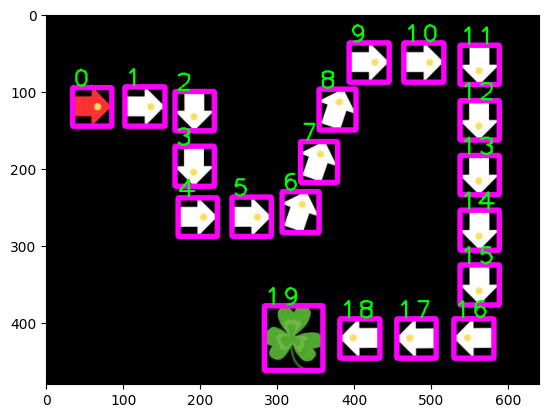

In [96]:
easy.algorithm()
easy.visualize_result()

[3, 8, 13, 16, 14, 9, 10]
[6, 1, 2, 7, 11, 15, 19, 21, 27, 29, 24, 22, 26, 28, 25]


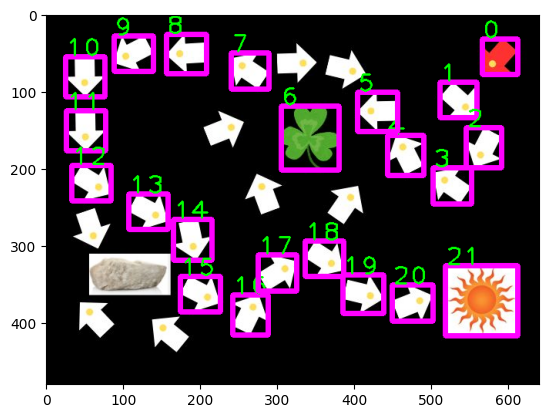

In [94]:
medium.algorithm()
medium.visualize_result()

[4, 8, 14, 18, 15, 10, 11]
[7, 3, 2, 1, 9]
[17, 22, 21, 26, 33, 35]
[37, 38, 32]


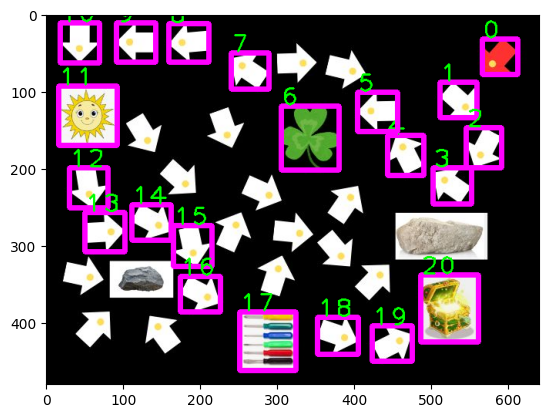

In [95]:
hard.algorithm()
hard.visualize_result()